In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression       
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")   # use your dataset path
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


NameError: name 'df' is not defined

In [4]:
df.isnull().sum()

df.dropna(inplace=True)

In [5]:
df.isnull().sum()

df.dropna(inplace=True)

In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\ayush\AppData\Local\Temp\ipykernel_23332\4134231849.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [7]:
X = df.drop("Churn", axis=1)   # target column
y = df["Churn"]

In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

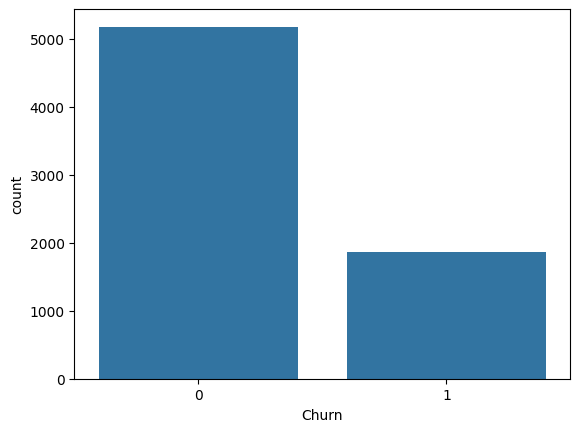

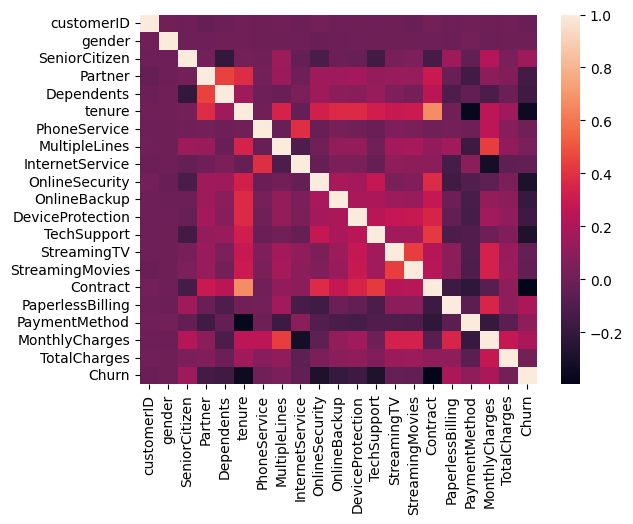

In [10]:
df.describe()

sns.countplot(x='Churn', data=df)
plt.show()

sns.heatmap(df.corr(), annot=False)
plt.show()

In [11]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [12]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8147622427253371
[[940  96]
 [165 208]]


In [15]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Random Forest Accuracy: 0.8147622427253371
[[940  96]
 [165 208]]


In [17]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_lr)

print(acc_lr, acc_rf)

0.8147622427253371 0.8147622427253371


In [19]:
import pickle

pickle.dump(lr, open("model.pkl", "wb"))

In [1]:
! pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
  Using cached streamlit-1.55.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached pyarrow-23.0.1-cp313-cp313-win_amd64.whl.metadata (3.1 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jsonschema-4.2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ayush\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("model.pkl", "rb"))

st.title("Customer Churn Prediction")

# Example inputs (modify according to dataset)
tenure = st.number_input("Tenure")
monthly_charges = st.number_input("Monthly Charges")

if st.button("Predict"):
    input_data = np.array([[tenure, monthly_charges]])
    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("Customer will churn")
    else:
        st.success("Customer will stay")

2026-03-25 13:29:00.197 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 13:29:04.274 
  command:

    streamlit run C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-25 13:29:04.277 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 13:29:04.280 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 13:29:04.283 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 13:29:04.285 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 13:29:04.289 Thread 'MainThread': missing ScriptRunContext! This w

In [4]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import pickle

# dataset load
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# sirf 2 columns use karo
X = df[['tenure', 'MonthlyCharges']]
y = df['Churn']

# Churn ko numeric banao (Yes=1, No=0)
y = y.map({'Yes': 1, 'No': 0})

# model train
model = LogisticRegression()
model.fit(X, y)

# save model
pickle.dump(model, open("model.pkl", "wb"))

print("✅ Model successfully trained and saved!")

✅ Model successfully trained and saved!
